In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
stats = pd.read_csv("data_mean_stdev_pix.txt", sep=' ', header= None)
stats.columns= ["name", "x_mean", "x_mean_std", "x_std_mean", "x_std_std", "y_mean", "y_mean_std", "y_std_mean", "y_std_std"]

In [3]:
x_data = pd.read_csv("Xarray_D1638_11-04_13:49.029886.csv", sep=' ', header= None)
x_data.columns= ["x_profile", "x"]

y_data = pd.read_csv("Yarray_D1638_11-04_13:49.029886.csv", sep=' ', header= None)
y_data.columns= ["y_profile", "y"]

In [4]:
x_error = np.sqrt(np.absolute(x_data["x_profile"]))
y_error = np.sqrt(np.absolute(y_data["y_profile"]))

    - Randomly sample a gaussian from the ys
    - do the same calculation of mean and std
    - repeat 1000+ times
    - now you should have a distribution of means and a distribution of stds (both should be normal). get mean and std of these TWO also using the same method
    - now you have avg_mean +/-sig_mean and avg_std+/-sig_std 

In [5]:
i = 0
iter_num = 50000
xmc_data = [0 for i in range(0,iter_num)]

while(i<iter_num):
    xmc_data[i] = np.random.normal(x_data["x_profile"], x_error)
    i = i + 1

for i in range (0, iter_num):
    plt.plot(x_data["x"], xmc_data[i])
#plt.xlim(250,270)
#plt.ylim(4000,10000)

plt.xlabel("Pixel")
plt.ylabel("Counts")

#plt.savefig("MC_zoomedin", dpi = 300)
plt.savefig("MC_sim", dpi = 300)

plt.show()

In [15]:
def findMean(xx, prof):
    avg_x = []
    norm = []

    avg_x = np.sum(np.multiply(xx, prof**2))
    norm = np.sum(prof**2)

    avg = avg_x/norm
    return avg

def findSTD(xx, prof, avg):
    prof = prof[int(avg-100):int(avg+100)]
    xx = xx[int(avg-100):int(avg+100)]

    avg_x = 0
    avg_x2 = 0
    norm = 0

    avg_x = np.sum(np.multiply(xx, prof**2))
    avg_x2 = np.sum(np.multiply(xx**2, prof**2))
    norm = np.sum(prof**2)
    
    avg = avg_x/norm
    std = np.sqrt(avg_x2/norm - avg**2)
    return std

In [7]:
xmc_mean = [0 for i in range(0,iter_num)]
xmc_std = [0 for i in range(0,iter_num)]

for k in range(0, iter_num):
    xmc_mean[k] = findMean(x_data["x"].values, xmc_data[k])
    xmc_std[k] = findSTD(x_data["x"].values, xmc_data[k], xmc_mean[k])

xmc_mean = np.array(xmc_mean)
xmc_std = np.array(xmc_std)

In [8]:
len(xmc_mean), len(xmc_std)

(50000, 50000)

* Now I have a distribution of means (xmc_mean) and a distribution of stds (xmc_std) (both should be normal). 
* Get mean and std of these two distributions now also using the same method (findMean and findSTD fns)

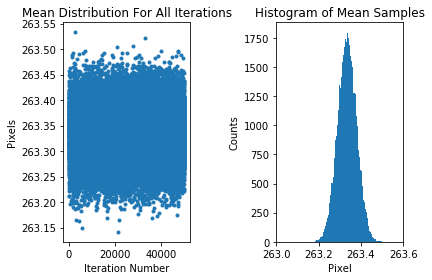

In [161]:
fig, axs = plt.subplots(nrows=1, ncols=2)
ax = axs[0]
ax1= axs[1]

ax.plot(xmc_mean, marker='.', linewidth=0)
ax1.hist(xmc_mean, bins=100)
ax1.xaxis.set_ticks(np.arange(263, 263.7, 0.2))


ax1.set_xlabel("Pixel")
ax1.set_ylabel("Counts")
ax1.set_title("Histogram of Mean Samples")
ax.set_ylabel("Pixels")
ax.set_xlabel("Iteration Number")
ax.set_title("Mean Distribution For All Iterations")

plt.tight_layout()
plt.savefig("x_mean_hist", dpi = 300)

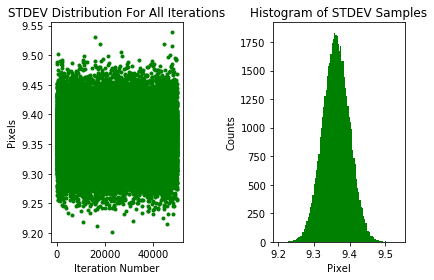

In [163]:
fig, axs = plt.subplots(nrows=1, ncols=2)
ax = axs[0]
ax1= axs[1]

ax.plot(xmc_std, marker='.', linewidth=0, color='g')
ax1.hist(xmc_std, bins=100, color='g')
#ax1.xaxis.set_ticks(np.arange(263, 263.7, 0.2))


ax1.set_xlabel("Pixel")
ax1.set_ylabel("Counts")
ax1.set_title("Histogram of STDEV Samples")
ax.set_ylabel("Pixels")
ax.set_xlabel("Iteration Number")
ax.set_title("STDEV Distribution For All Iterations")

plt.tight_layout()
plt.savefig("x_std_hist", dpi = 300)

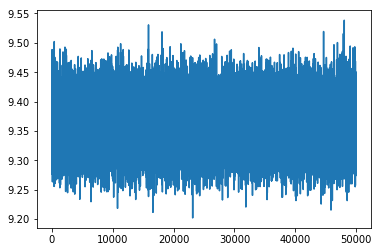

In [10]:
plt.plot(xmc_std)
plt.show()

In [11]:

avg_mean = np.mean(xmc_mean)
std_mean = np.std(xmc_mean)

avg_std = np.mean(xmc_std)
std_std = np.std(xmc_std)

print(avg_mean, std_mean, avg_std, std_std)

263.33466242039884 0.04500873052640908 9.362325298048999 0.03768465219865106


In [25]:
x_pics =  np.arange(1,51)

P.S. 5 mm is 41 pixels

Text(0.5, 1.0, 'Mean')

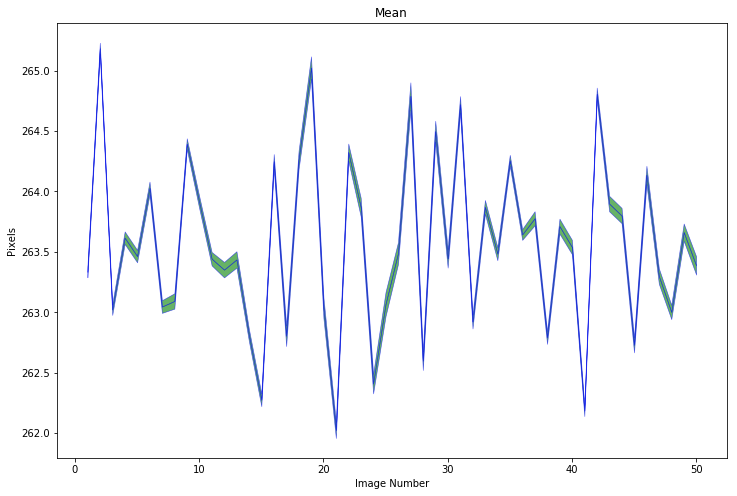

In [112]:
plt.figure(figsize=(12,8))
plt.fill_between(x_pics, stats['x_mean'],stats['x_mean']+stats["x_mean_std"], alpha=0.6, edgecolor='b', facecolor='g', linewidth=0.6, antialiased=True)           
plt.fill_between(x_pics, stats['x_mean'],stats['x_mean']-stats["x_mean_std"], alpha=0.6, edgecolor='b', facecolor='g', linewidth=0.6, antialiased=True)

plt.xlabel("Image Number")
plt.ylabel("Pixels")
plt.title("Mean")

#plt.savefig("mean_images", dpi = 300)

Text(0.5, 1.0, 'STDEV')

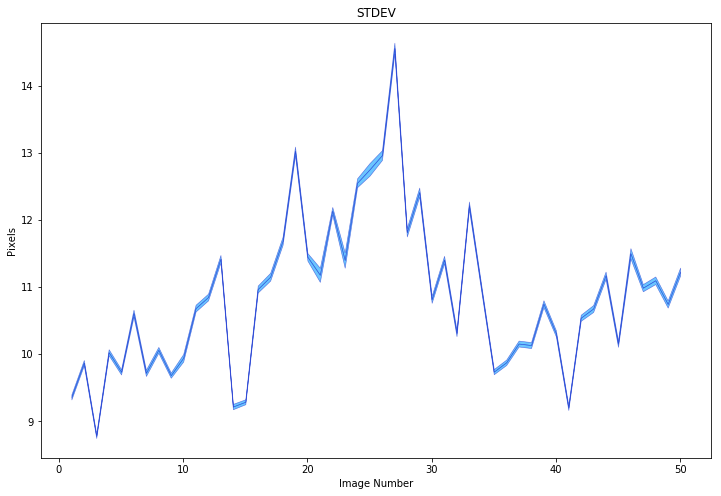

In [111]:
plt.figure(figsize=(12,8))
plt.fill_between(x_pics, stats['x_std_mean'],stats['x_std_mean']+stats["x_std_std"], alpha=0.6, edgecolor='#1B2ACC', facecolor='#089FFF', linewidth=0.6, antialiased=True)           
plt.fill_between(x_pics, stats['x_std_mean'],stats['x_std_mean']-stats["x_std_std"], alpha=0.6, edgecolor='#1B2ACC', facecolor='#089FFF', linewidth=0.6, antialiased=True)  

plt.xlabel("Image Number")
plt.ylabel("Pixels")
plt.title("STDEV")

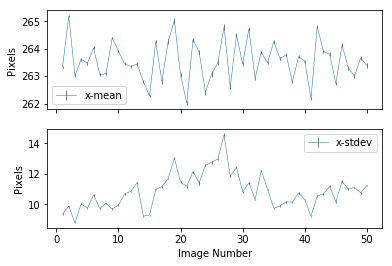

In [110]:

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True)
ax = axs[0]
ax1= axs[1]

ax.errorbar(x_pics, stats['x_mean'], yerr =stats["x_mean_std"], linewidth=0.5, ecolor='black', capthick=2, label="x-mean")
ax.legend()

ax1.errorbar(x_pics, stats['x_std_mean'], yerr = stats["x_std_std"],linewidth=0.5, ecolor='black', capthick=2, label='x-stdev')
ax1.legend()

ax1.set_xlabel("Image Number")
ax1.set_ylabel("Pixels")
ax.set_ylabel("Pixels")

plt.savefig("x_mean_stdev_allim", dpi = 300)

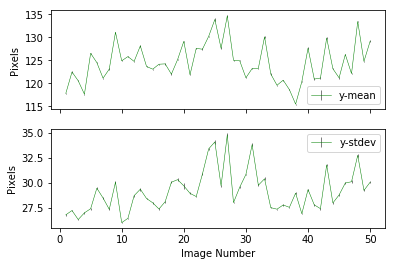

In [109]:

fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True)
ax = axs[0]
ax1= axs[1]

ax.errorbar(x_pics, stats['y_mean'], yerr =stats["y_mean_std"], linewidth=0.5, ecolor='black', color = 'g', capthick=2, label="y-mean")
ax.legend()
ax.locator_params(nbins=6)

ax1.errorbar(x_pics, stats['y_std_mean'], yerr = stats["y_std_std"],linewidth=0.5, ecolor='black', color = 'g', capthick=2, label='y-stdev')
ax1.legend()

ax1.set_xlabel("Image Number")
ax1.set_ylabel("Pixels")
ax.set_ylabel("Pixels")

plt.savefig("y_mean_stdev_allim", dpi = 300)

In [119]:
print("Max x: ",np.max(stats['x_mean']), "Min x: ", np.min(stats['x_mean']))
print("Max y: ",np.max(stats['y_mean']), "Min x: ", np.min(stats['y_mean']))

Max x:  265.18322323395694 Min x:  262.0273102726456
Max y:  134.64129423414002 Min x:  115.46229813495978


In [117]:
print("X range in  mm ", (265.18322323395694 -262.0273102726456)*5/41)
print("Y range in  mm ", (134.64129423414002 -115.46229813495978)*5/41)

X range in  mm  0.38486743430626147
Y range in  mm  2.3389019633146635


In [124]:
print("Max x: ",np.max(stats['x_std_mean']), "Min x: ", np.min(stats['x_std_mean']))
print("Max y: ",np.max(stats['y_std_mean']), "Min x: ", np.min(stats['y_std_mean']))

Max x:  14.562363303728276 Min x:  8.782370351864703
Max y:  34.779079634711515 Min x:  26.02638713204636


In [126]:
print("X size in  mm ", (14.562363303728276*2)*5/41)
print("Y size in  mm ", (34.779079634711515*2)*5/41)

X size in  mm  3.551795927738604
Y size in  mm  8.482702349929637


In [134]:
print("fraction of x spot size in movement: ", 0.38/3.55*100, "%")

fraction of x spot size in movement:  10.704225352112678 %


In [133]:
print("fraction of y spot size in movement: ",2.34/8.42*100, "%")

fraction of y spot size in movement:  27.790973871733964 %


In [ ]:
This corresponds to Im#2 and Im#21 in x, and Im#27 and Im#38 in y. 


Testing image 32


In [2]:
#y_smooth= [449, 112, -244, -189, 1015, 209, 39, -239, -255, 297, 170, -281, -101, 111, -93, 633, -149, 450, -81, 178, -131, -424, -340, 450, 0, -447, -382, 1330, 481, 161, -74, 126, 28, 560, -244, 204, 10, 832, -16, -29, 529, -331, 99, 197, 696, 13, 724, -78, 40, 678, -177, -131, 351, 612, 662, 763, -46, 1026, 787, 792, -170, 551, 334, 1202, 1136, -34, 1143, 1015, 651, 1078, -526, 1340, 913, 867, 679, 919, -166, 758, 691, 987, 1310, 508, 701, 1770, 1326, 1604, 1386, 922, 1028, 1507, 1033, 1822, 1569, 1480, 1171, 1518, 1630, 1456, 908, 962, 1548, 1983, 1625, 1430, 1179, 613, 1386, 716, 1290, 1714, 1801, 1985, 1551, 2295, 1465, 1447, 2564, 2384, 1425, 1667, 1739, 1727, 1615, 1463, 2308, 2162, 1273, 1645, 2180, 1546, 1291, 2440, 1358, 1888, 1923, 2208, 2054, 1714, 2012, 2579, 1387, 1520, 2186, 1119, 1788, 1923, 1270, 1406, 1088, 1723, 723, 1148, 1305, 196, 862, 1006, -97, 596, 861, 837, 1048, 969, 445, 21, 1064, 449, 654, 572, 500, 535, 616, 458, 663, -111, 219, 483, 985, 661, -632, 472, 226, 265, -62, 847, 259, -268, 445, 584, 119, 246, 385, 189, 618, 241, -345, 516, -5, 1243, 257, 862, 928, 583, -18, 608, 90, 223, 355, 406, 195, 47, 952, 191, 899, 92, -298, 911, -332, 404, 443, 223, 131, 946, 961, -38, 377, 610, 622, 608, 418, 579, 1111, 1319, 716, -124, 468, 363, 389, -32, 323, 528, 681, 583, 483, -222, 1151, 115, 289, 446, 279, -719, 235, 962, -504, 377, 509, 162, 200, 364, 216, 664, 244, 421, 638, 739, 374, -181, 248, 224, 519, 340, 949, 318, 888, 17, 111, 661, 1056, 233, 734, 268, -37, 476, -248, 236, 493, 882, 292, 352, 280, 633, 274, 479, -230, 614, -248, -457, -385, 600, 291, 214, -67, 526, -461, 200]

#y_smooth= [449, 112, -244, -189, 1015, 209, 39, -239, -255, 297, 170, -281, -101, 111, -93, 633, -149, 450, -81, 178, -131, -424, -340, 450, 0, -447, -382, 1330, 481, 161, -74, 126, 28, 560, -244, 204, 10, 832, -16, -29, 529, -331, 99, 197, 696, 13, 724, -78, 40, 678, -177, -131, 351, 612, 662, 763, -46, 1026, 787, 792, -170, 551, 334, 1202, 1136, -34, 1143, 1015, 651, 1078, -526, 1340, 913, 867, 679, 919, -166, 758, 691, 987, 1310, 508, 701, 1770, 1326, 1604, 1386, 922, 1028, 1507, 1033, 1822, 1569, 1480, 1171, 1518, 1630, 1456, 908, 962, 1548, 1983, 1625, 1430, 1179, 613, 1386, 716, 1290, 1714, 1801, 1985, 1551, 2295, 1465, 1447, 2564, 2384, 1425, 1667, 1739, 1727, 1615, 1463, 2308, 2162, 1273, 1645, 2180, 1546, 1291, 2440, 1358, 1888, 1923, 2208, 2054, 1714, 2012, 2579, 1387, 1520, 2186, 1119, 1788, 1923, 1270, 1406, 1088, 1723, 723, 1148, 1305, 196, 862, 1006, -97, 596, 861, 837, 1048, 969, 445, 21, 1064, 449, 654, 572, 500, 535, 616, 458, 663, -111, 219, 483, 985, 661, -632, 472, 226, 265, -62, 847, 259, -268, 445, 584, 119, 246, 385, 189, 618, 241, -345, 516, -5, 1243, 257, 862, 928, 583, -18, 608, 90, 223, 355, 406, 195, 47, 952, 191, 899, 92, -298, 911, -332, 404, 443, 223, 131, 946, 961, -38, 377, 610, 622, 608, 418, 579, 1111, 1319, 716, -124, 468, 363, 389, -32, 323, 528, 681, 583, 483, -222, 1151, 115, 289, 446, 279, -719, 235, 962, -504, 377, 509, 162, 200, 364, 216, 664, 244, 421, 638, 739, 374, -181, 248, 224, 519, 340, 949, 318, 888, 17, 111, 661, 1056, 233, 734, 268, -37, 476, -248, 236, 193, 1182, 1192, 1052, 580, 1433, 1074, 1379, -230, 14, -248, -457, -385, 1415, 291, 514, -67, 226, -461, 779]
#x_smooth= [150, -92, -396, -638, -309, 921, -337, 165, -419, -30, -247, -65, 294, 263, 55, -119, 416, 320, 459, 368, -618, -578, 287, -403, 229, 87, 154, 231, 388, -24, 232, -172, 249, 606, 665, 79, 204, -308, -123, 139, 79, -352, 202, 256, -252, 77, 481, 479, 576, -85, -362, 325, -45, -26, 223, 159, -146, -83, 91, -127, 530, -92, 496, -66, -383, 56, 73, 122, 350, -173, 535, 243, -486, -17, 14, 146, 322, -90, -301, -388, -151, 163, -154, 274, 178, -4, -3, 423, 19, 567, 695, 497, -216, 314, -560, 268, -162, -162, -149, 443, 167, 119, 185, -391, -778, 551, -222, -174, 0, 169, 834, 62, -165, -192, 154, 103, -105, -594, 158, 247, -354, -127, 84, 658, 600, 261, 758, 651, 265, -252, -148, -285, 0, 39, 139, 225, 590, 395, 0, -452, -166, 132, -86, 340, 103, 283, 22, -60, 7, 720, 180, -362, -188, 170, 397, 141, 7, -29, 17, 450, 445, -561, -144, 107, 324, 79, 317, 144, 445, 900, 297, 134, 417, 126, 545, -67, 290, -285, -215, 193, 60, -179, 111, 635, 479, 350, 20, 1194, -100, -88, 505, 579, 314, 21, 570, 101, -293, 259, 366, 76, -53, 312, 155, 248, 340, -177, 530, 393, 234, -324, 439, 153, -34, -166, 478, 87, 463, 267, 213, 177, -210, -525, 634, 535, -44, 7, 130, -253, -252, 378, 4, 200, 37, 528, 123, 384, -13, -340, 269, 810, 75, 604, 288, 166, 1290, 1675, 988, 1609, 2238, 2112, 2595, 2975, 3328, 3592, 3703, 4200, 4595, 5305, 4694, 4814, 5392, 5402, 5811, 5919, 5963, 5171, 5131, 4965, 4923, 4761, 4142, 3660, 3197, 2945, 2635, 1868, 1406, 1115, 842, 892, 601, 738, 753, -157, 529, 279, 263, 146, 583, -7, 87, 192, 856, 188, 137, 223, 120, 37, -139, 150, 174, 609, 137, -17, -48, 128, 467, -471, 752, 74, -66, 286, 358, 74, -132, 148, 19, -243, 10, 177, 133, 133, -96, 314, -575, 92, -215, 429, 187, -184, 80, 371, -106, -144, -148, 317, 177, 610, 669, 150, 237, 99, 434, 115, 302, 325, -319, 406, 514, 677, 126, 77, 211, 102, -140, 740, 65, -355, -140, 476, 392, 126, -50, 393, 191, -198, -316, -46, 9, -313, 474, 383, 119, 170, -18, -40, 203, 535, -317, 159, -151, 614, 316, 31, -385, 134, 321, -339, 3, -207, 84, 287, 324, 341, -104, 347, 374, -320, -365, -295, -161, -449, 715, 347, 345, 387, -8, 136, 521, 185, 527, -60, 219, 259, 880, 266, 521, 549, 61, 47, 800, 550, 68, 469, 422, 587, 435, 293, -236, -456, -201, 299, 345, 302, 747, -258, -486, 358, -387, 278, 279, 153, 400, 411, 12, 589, 625, 537, 458, -213, -31, 39, -448, 143, 225, 835, 673, 850, 270, 536, -45, 119, 501, 123, -51, 381, 1267, 336, 449, 62, 818, 593, 144, 624, 364, 430, 548, 12, 671, -37, 447, 353, 315, 322, -9, 445, 851, -31, 293, 24, 155, 203, 384, 328, 197, -156, 338, 81, 119, -11, 164, 96, -293, 360, -532, 597, 251, -200, 244, -448, -44, -525, 624, -264, -84, 290, 48, -426, 495, 754, 0, -106, 149, 38, -21, 423, 424, 496, 205, 367] 

#image 48

x_smooth= [-162, -192, -648, -64, -15, -76, -497, 400, -481, -253, -580, -216, 59, -127, 88, -138, -87, -242, -38, 62, -707, -601, 76, -69, 362, -39, -525, 167, -113, -38, 26, -685, -243, -219, 77, -269, 155, -457, -70, -339, 267, -636, -403, -466, -479, -23, 8, 174, 712, -384, -528, -283, -85, -481, -516, -156, -672, -351, 345, -261, 291, 160, 73, 42, -205, -154, -188, -534, 904, -304, 170, -130, 58, -34, 19, -620, 113, -451, -483, -394, -155, -623, -275, -31, -207, -544, -201, 198, -302, -123, 212, -452, -412, -122, -287, 154, -309, -259, -198, 202, -218, 142, -218, -4, -284, 422, 74, -508, -550, -397, 65, -98, -94, -726, -126, -374, -653, -530, 18, -437, -871, -315, -29, -38, 122, 80, 371, 354, 262, -448, -486, -499, -130, 517, -8, 228, 314, 221, -209, -402, -99, -151, -45, 266, -724, -340, -693, -179, -374, 224, -118, -390, -756, -358, 692, -348, -399, -153, -272, -414, 106, -368, -407, 62, -54, 148, 37, 115, 622, 504, -184, 101, -432, -156, -94, -325, 33, -296, -356, 2, -342, -591, -293, -100, 272, -468, -566, 565, -15, 19, -248, 104, 536, -192, 167, 120, -362, -174, -377, -524, -378, -95, -217, -217, -207, -68, 196, -13, -265, -408, -127, -487, -333, -304, 283, -278, 253, -429, 109, -173, -483, -450, -597, 342, -405, -185, -364, -377, -184, 104, -193, -484, -124, -2, -186, 151, 53, -69, -1, 138, 51, 154, -59, 113, 603, 1934, 1330, 2119, 2411, 3078, 3423, 3785, 3937, 4606, 4658, 4929, 6196, 5881, 5964, 6762, 7077, 7138, 7243, 8026, 7574, 6649, 6713, 6473, 6558, 5917, 5339, 4616, 3607, 3178, 3316, 2632, 1769, 1635, 714, 958, 814, 520, 603, 426, 103, 305, 350, -177, 410, 318, -514, 44, 44, -97, 199, -182, -363, -514, -92, -9, -126, 530, -103, -825, -385, -549, 433, -452, 397, 54, 85, 221, 566, 227, -245, -206, 14, 152, -292, 550, -522, 99, 58, -315, -689, -341, -423, -35, 90, -411, -215, 425, -312, -390, -224, -37, 207, -101, -300, 327, -183, 232, -198, 433, 409, 0, -410, -12, -181, 61, -317, -61, -15, -231, -438, 9, 356, -540, -253, -43, 30, 438, -532, 71, -75, -200, -181, 181, 280, -476, 26, -217, 244, -38, 16, -395, 172, -203, 81, -252, -522, 255, 72, 534, -428, -12, -35, -247, 59, 98, -115, -46, 258, -77, -472, -353, 616, -331, -477, 32, -384, -224, 351, -230, -241, 227, -37, 357, 352, 511, 308, -282, -218, -36, 519, 298, 476, 134, -65, -308, 278, 618, 0, 499, 265, 143, 36, 286, -454, -280, -95, 97, 238, 416, 180, 110, -477, 205, -115, 297, 130, 48, 117, 99, -97, 722, -56, 341, 164, -725, 207, -254, -150, 84, -109, 382, 402, 443, 166, 340, -358, 296, 398, -136, 103, 185, 698, -64, 44, -496, 457, 488, -201, 183, -117, -118, 460, 146, 282, -389, -197, -382, 119, 343, -617, 334, 758, -67, 31, -290, -74, -247, -99, 216, 157, -74, 458, -148, -352, -75, -84, -7, -478, 473, -52, 426, 162, 453, 175, -106, -157, -503, 464, 62, -294, -360, -196, -609, 133, 571, -107, -429, 72, -401, -143, 422, -140, 124, -139, 62]
y_smooth= [-492, -551, -1278, -1142, -470, -463, -877, -312, -677, -1241, -179, -929, -12, -627, -120, 33, -578, -93, -592, -304, -322, -758, -695, -286, -967, -449, -765, -197, -350, 34, -146, -368, -615, 62, -557, -932, -577, -81, -552, 386, 32, -571, 52, -626, -126, -2, -348, -209, 68, -76, -214, -623, 265, 222, -85, -11, 101, 150, -106, 477, 505, 432, 857, 365, 396, 405, 497, 1025, 1182, 883, -628, 635, 682, 1065, 695, 1215, 884, 1129, 560, 960, 1099, 1215, 1008, 1949, 1571, 1243, 1634, 902, 1773, 1893, 1656, 2152, 1588, 1753, 1147, 2168, 1655, 1854, 1543, 1258, 1325, 1648, 1630, 2005, 1949, 1694, 1628, 1027, 1678, 1799, 1947, 2249, 2150, 1985, 2132, 1766, 2106, 2856, 1317, 1539, 2322, 1947, 1831, 2726, 2204, 2181, 2124, 1910, 2493, 2126, 2032, 2509, 1634, 2537, 2254, 2244, 2183, 1116, 1347, 2286, 1312, 2038, 1293, 889, 1811, 1839, 926, 1513, 1723, 1468, 582, 1136, 831, 300, 499, 73, -438, 426, 788, 309, 420, 255, 413, 250, 572, 156, 528, -164, -55, 980, 350, -199, 92, -126, -952, -758, 515, -155, -140, 204, 527, 346, -213, 137, 5, -185, -21, 156, -129, 243, 291, -206, 978, -210, -524, -499, -397, -577, 254, 356, 208, -215, -125, 134, -323, -230, -681, -300, -32, -301, 548, -582, 522, -679, -275, -116, -479, 80, 508, 511, -446, 69, -11, -286, 242, 295, -393, -315, 123, -117, 300, 427, 714, -241, 190, 795, -413, -82, -16, 434, 368, -158, -558, -159, 476, -74, 652, -342, 183, -243, -392, 557, -212, 353, 177, -240, 186, 396, 430, 249, -487, 400, -315, -480, 43, -304, -1073, -145, 115, 34, 150, -95, 527, -902, -847, 291, 1003, 33, 517, 614, -334, 106, -102, 253, -14, 120, 459, 294, 469, 140, 560, 677, -167, -428, -701, 128, -441, 447, -465, 642, 74, -337, -412, -274]

x= [  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
       182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194,
       195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207,
       208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220,
       221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233,
       234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246,
       247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259,
       260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272,
       273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285,
       286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298,
       299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311,
       312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324,
       325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 335, 336, 337,
       338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350,
       351, 352, 353, 354, 355, 356, 357, 358, 359, 360, 361, 362, 363,
       364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376,
       377, 378, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389,
       390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402,
       403, 404, 405, 406, 407, 408, 409, 410, 411, 412, 413, 414, 415,
       416, 417, 418, 419, 420, 421, 422, 423, 424, 425, 426, 427, 428,
       429, 430, 431, 432, 433, 434, 435, 436, 437, 438, 439, 440, 441,
       442, 443, 444, 445, 446, 447, 448, 449, 450, 451, 452, 453, 454,
       455, 456, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467,
       468, 469, 470, 471, 472, 473, 474, 475, 476, 477, 478, 479, 480,
       481, 482, 483, 484, 485, 486, 487, 488, 489, 490, 491, 492, 493,
       494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506,
       507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519,
       520, 521, 522, 523, 524, 525, 526, 527, 528, 529]
y= [  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181,
       182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194,
       195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207,
       208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220,
       221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233,
       234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246,
       247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259,
       260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272,
       273, 274, 275, 276, 277, 278, 279, 280, 281, 282, 283, 284, 285,
       286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 296, 297, 298,
       299, 300, 301, 302, 303]


In [3]:
def findMean(xx, prof):
    avg_x = []
    norm = []


    #prof_norm = (prof- np.mean(prof))/np.std(prof)
    #prof = prof_norm
    #weighted sum to get weighted average
    avg_x = np.sum(np.multiply(xx, prof))
    #sum of counts
    norm = np.sum(prof)

    avg = avg_x/norm
    
    return avg


def findSTD(xx, prof, avg):
    prof = prof[int(avg-50):int(avg+50)]
    xx = xx[int(avg-50):int(avg+50)]

    mean_diff = 0
    weighted_diff = 0
    norm = 0

    mean_diff = (xx - avg)**2
    weighted_diff = np.abs(np.sum(prof*mean_diff))
    
    norm = np.abs(np.sum(prof))

    std = np.sqrt(weighted_diff/(norm*(1-1/len(prof))))
    
    #if (len(xx)==230):
        #print(std, weighted_diff, norm*(1-1/len(prof)) )
    
    return std

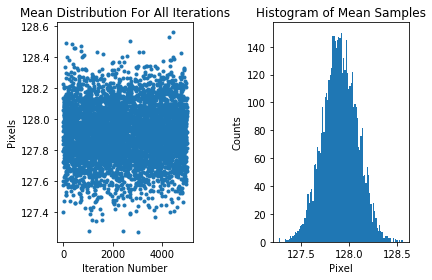

In [4]:
y_smooth = y_smooth[:220]
y = y[:220]

y_error = np.sqrt(np.absolute(y_smooth))

i = 0
iter_num = 5000
ymc_data = [0 for i in range(0,iter_num)]

while(i<iter_num):
    ymc_data[i] = np.random.normal(y_smooth, y_error)
    i = i + 1

#y = np.arange(len(y_smooth))
    
ymc_mean = [0 for i in range(0,iter_num)]
ymc_std = [0 for i in range(0,iter_num)]

for k in range(0, iter_num):
    ymc_mean[k] = findMean(y, ymc_data[k])
    ymc_std[k] = findSTD(y, ymc_data[k], ymc_mean[k])

ymc_mean = np.array(ymc_mean)
ymc_std = np.array(ymc_std)

fig, axs = plt.subplots(nrows=1, ncols=2)
ax = axs[0]
ax1= axs[1]

ax.plot(ymc_mean, marker='.', linewidth=0)
ax1.hist(ymc_mean, bins=100)

ax1.set_xlabel("Pixel")
ax1.set_ylabel("Counts")
ax1.set_title("Histogram of Mean Samples")
ax.set_ylabel("Pixels")
ax.set_xlabel("Iteration Number")
ax.set_title("Mean Distribution For All Iterations")

plt.tight_layout()
#plt.savefig("x_mean_hist", dpi = 300)

In [6]:

avg_mean = np.mean(ymc_mean)
std_mean = np.std(ymc_mean)

avg_std = np.mean(ymc_std)
std_std = np.std(ymc_std)


In [7]:
avg_mean

127.90568239325593

In [52]:
avg_std

31.578044804006257

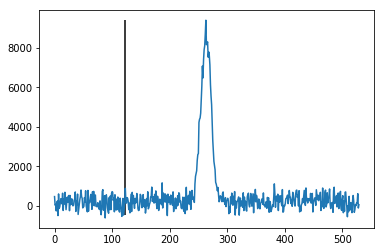

In [54]:
plt.plot(x_smooth)
plt.vlines(avg_mean, -500 ,np.max(x_smooth))

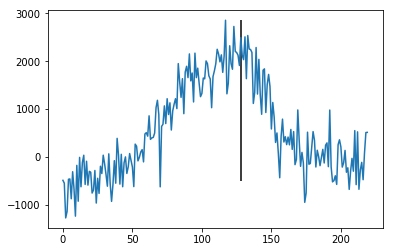

In [8]:
plt.plot(y_smooth)
plt.vlines(avg_mean, -500 ,np.max(y_smooth))
#plt.vlines(avg_std+avg_mean, -500 ,np.max(y_smooth))
#plt.vlines(avg_std-avg_mean, -500 ,np.max(y_smooth))


